# Dataset description
## Regions unemployment 2025 vs. 2026 first semester

**Source**: DANE

**Download**: [link](https://www.dane.gov.co/index.php/estadisticas-por-tema/mercado-laboral/por-regiones)

# Code
## Imports

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: "%.1f" % x)

## Load Data

In [12]:
path = "./data/regiones.csv"

df = pd.read_csv(path, encoding="utf-8")

## Clean data

In [13]:
REGION_EN = {
    "Total región Caribe": "Caribbean",
    "Total región Central": "Central",
    "Total región Oriental": "Eastern",
    "Total región Pacífica": "Pacific",
    "Total regiones Orinoquía, Amazonía e Insular*": "Orinoquia, Amazonia\n& Insular",
    "Bogotá D. C.": "Bogotá D.C.",
}

df_f = df[
    ~(df["Perspectiva"].str.lower().str.contains("nacional")) &
    (df["Periodo"].eq("I")) &
    (df["Concepto"].eq("Tasa de Desocupación (TD)")) &
    (df["Fecha"].isin([2025, 2026]))
]

df_f.drop(columns=["Concepto", "Periodo"], inplace=True)

df_f = df_f.pivot_table(
    values="Valor",
    index="Perspectiva",
    columns="Fecha"
)

df_f.columns.name = None
df_f.index.name = None
df_f.index = df_f.index.map(REGION_EN)

## Plot

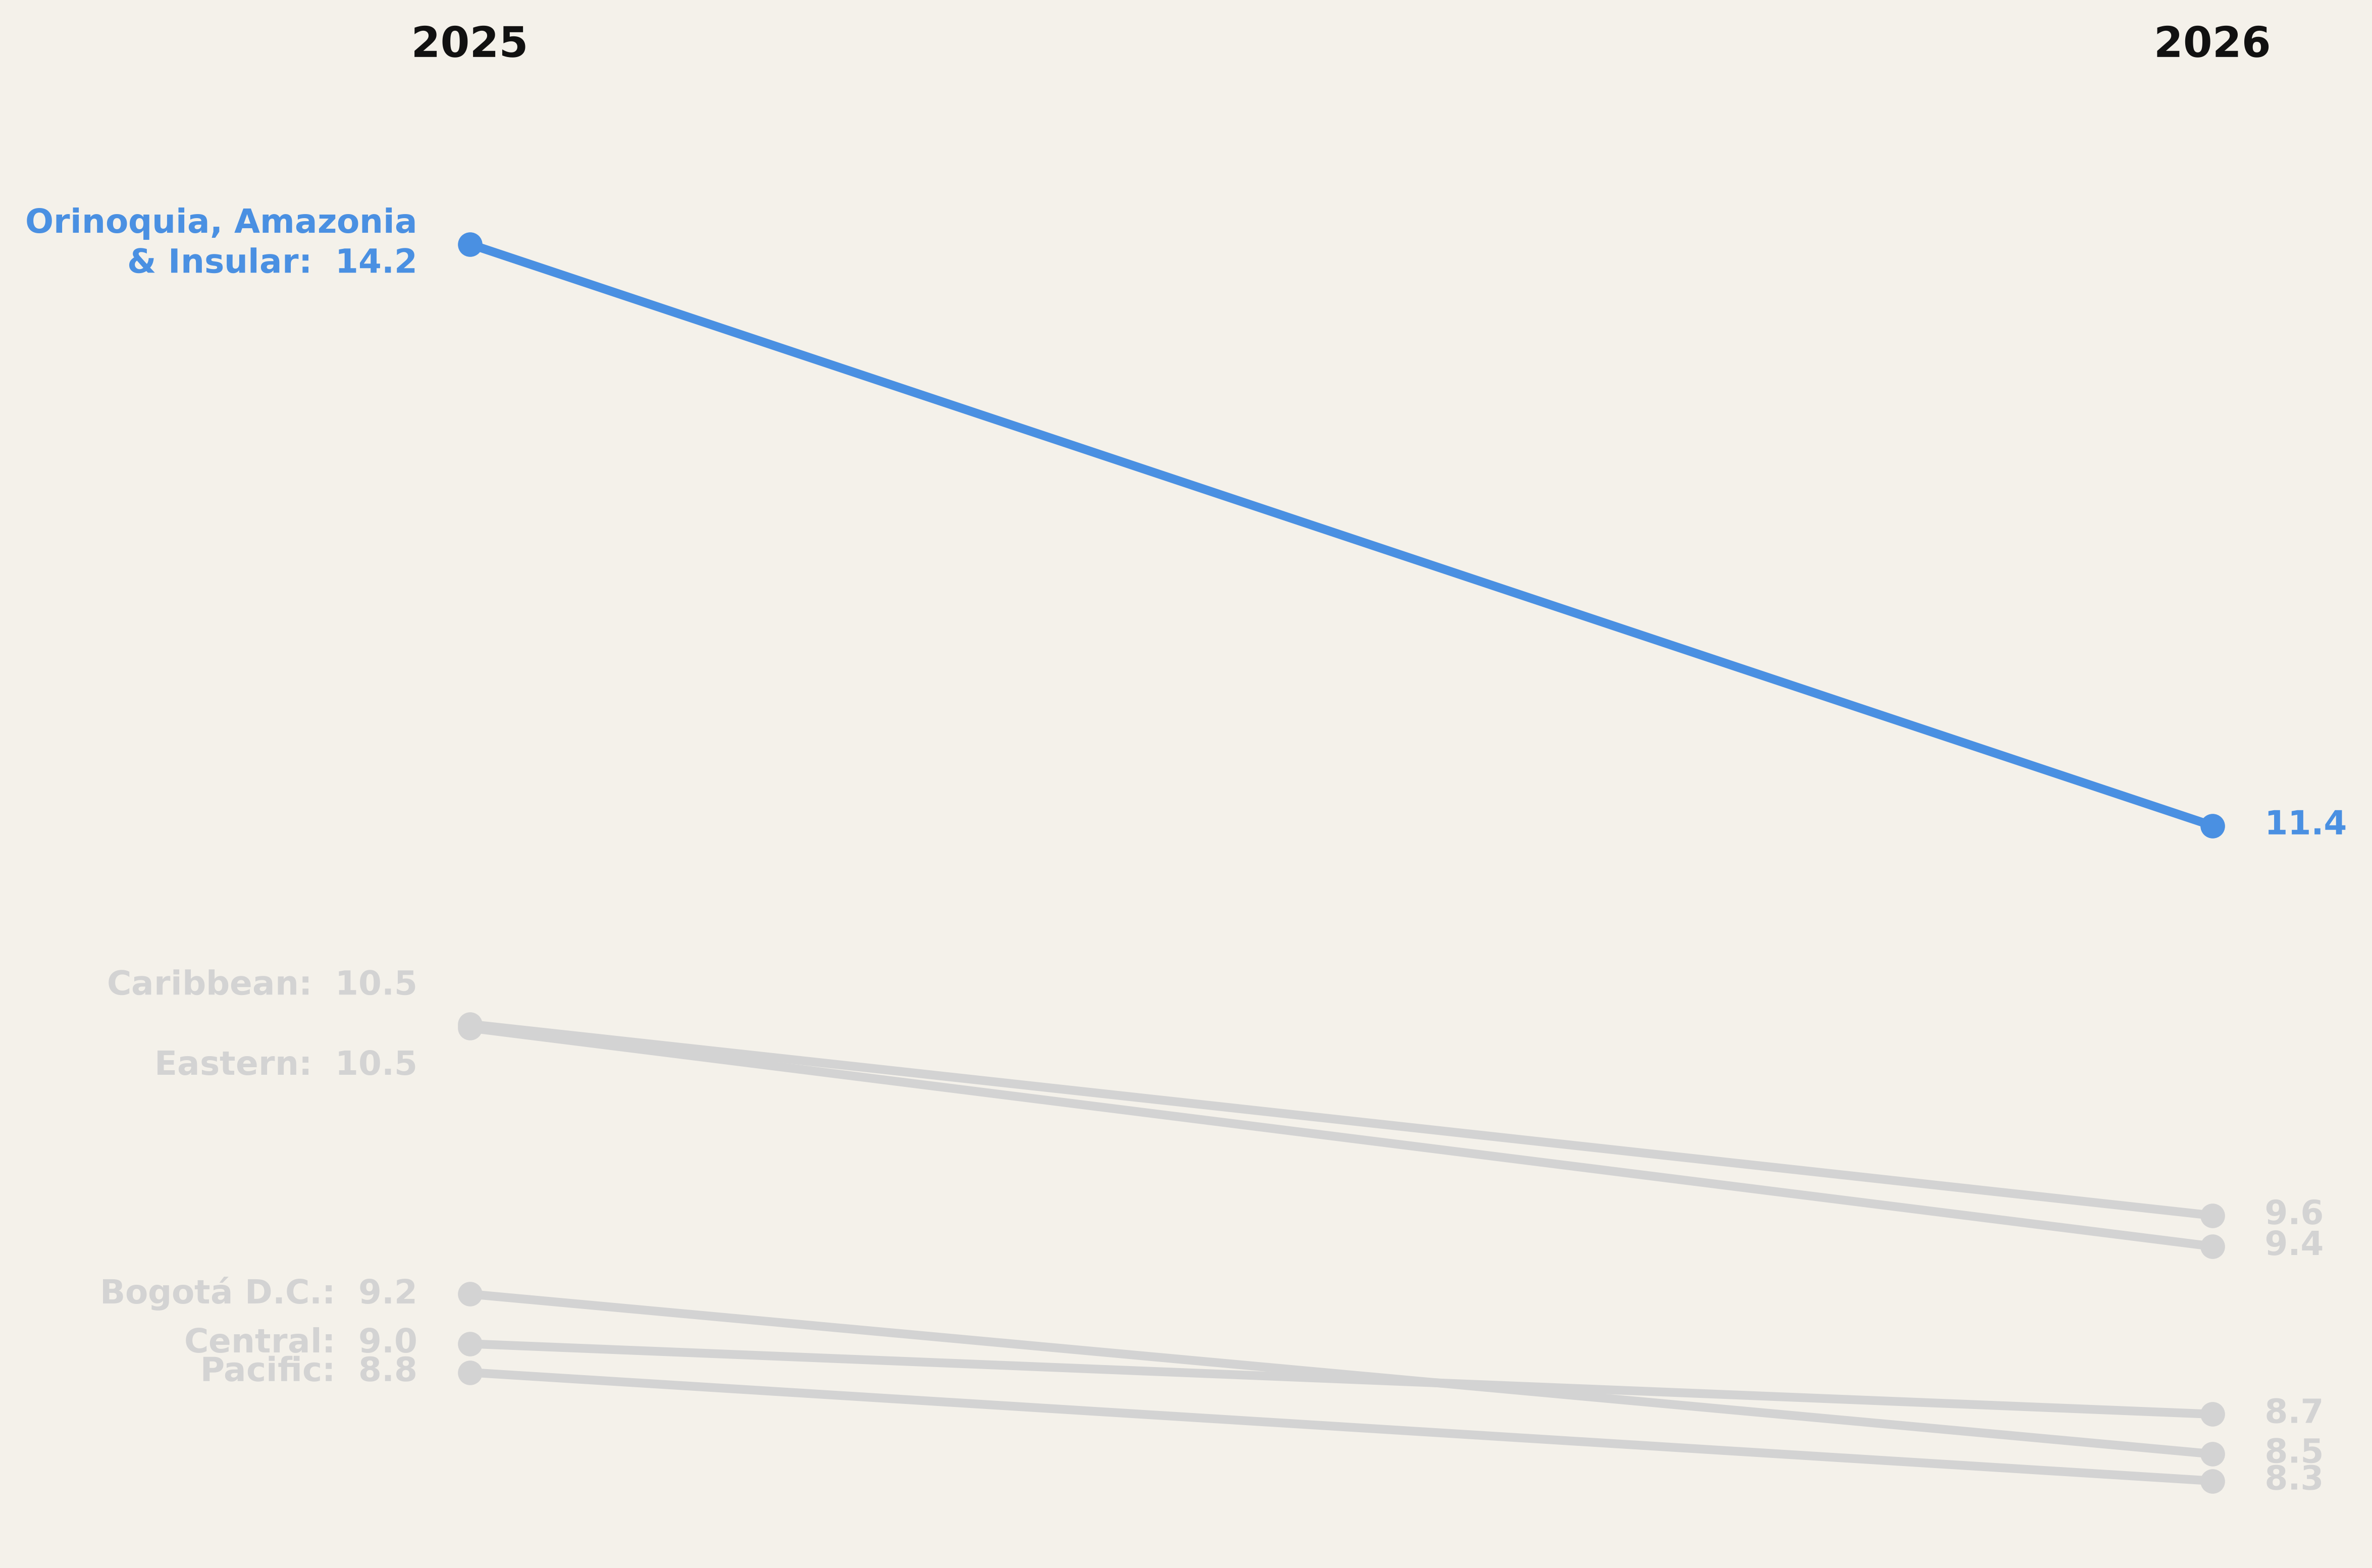

In [14]:
background = "#F4F1EA"
blue = "#4a90e2"

fig, ax = plt.subplots(figsize=(9.8, 7.0), dpi=500)
fig.patch.set_facecolor(background)
ax.patch.set_facecolor(background)

plt.text(
    0,
    15.0,
    "2025",
    ha="center",
    va="bottom",
    fontsize=12,
    fontweight="bold",
    color="#111111",
)
plt.text(
    1,
    15.0,
    "2026",
    ha="center",
    va="bottom",
    fontsize=12,
    fontweight="bold",
    color="#111111",
)

left_offsets = {
    "Caribbean": +0.18,
    "Eastern": -0.18, 
}

for i, (region, row) in enumerate(df_f.iterrows()):
    val_2025 = row[2025]  
    val_2026 = row[2026]  
    color = blue if region.startswith("Orinoquia") else "#D3D3D3"

    y_left = val_2025 + left_offsets.get(region, 0)

    plt.plot([0, 1], [val_2025, val_2026], color=color, lw=2.5, marker="o")

    plt.text(
        -0.03,
        y_left,
        f"{region}:  {val_2025:.1f}",
        ha="right",
        va="center",
        color=color,
        fontweight="bold",
        fontsize=9.5,
    )

    plt.text(
        1.03,
        val_2026,
        f"{val_2026:.1f}",
        ha="left",
        va="center",
        color=color,
        fontweight="bold",
        fontsize=9.5,
    )

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)
    
plt.axis("off")

plt.show()